# Controlled Ash burden-ratio sensitivity comparison

This notebook performs a deterministic one-factor-at-a-time sensitivity analysis of the dimensionless Ash burden ratio.

The Ash ratio varies from 20 to 40 while hole diameter and all other reconstructed Gole Gohar reference inputs remain fixed.

This analysis quantifies equation response and seven-model structural disagreement. It is not a field-validated design recommendation, calibrated uncertainty analysis, or optimization study.

**Decision gate:** `RESEARCH_COMPARATOR_ONLY`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from blastdesign import (
    build_ash_burden_ratio_ensemble_summary,
    build_gole_gohar_ash_burden_ratio_sensitivity_table,
    build_model_ash_burden_ratio_response_summary,
)


PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError(
        "Run this notebook from the BlastDesign-AI "
        "repository or its notebooks directory."
    )

DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs" / "figures"

DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: F:\Projects\BlastDesign-AI


## Method

The analysis uses the currently implemented Ash burden-ratio interval of 20–40 and samples it at increments of 2.5.

The reference value is 25. All other reconstructed scenario inputs remain fixed.

Because only the Ash equation contains this coefficient, the other six models act as deterministic controls. The sampled interval is not presented as a universal calibration domain or recommended operational range.

In [2]:
model_outputs = (
    build_gole_gohar_ash_burden_ratio_sensitivity_table()
)

ensemble_summary = (
    build_ash_burden_ratio_ensemble_summary(
        model_outputs
    )
)

model_response_summary = (
    build_model_ash_burden_ratio_response_summary(
        model_outputs
    )
)

display(model_outputs)
display(ensemble_summary)
display(model_response_summary)

,ash_burden_ratio,model_id,model_name,burden_m
0,20.0,CONV_ASH,Ash,5.020000
1,20.0,CONV_BHANDARI,Bhandari,6.874000
2,20.0,CONV_JIMENO,Lopez Jimeno,5.773000
3,20.0,CONV_KONYA_1972,Konya 1972,5.527324
4,20.0,CONV_KONYA_1983,Konya 1983,5.689716
...,...,...,...,...
58,40.0,CONV_JIMENO,Lopez Jimeno,5.773000
59,40.0,CONV_KONYA_1972,Konya 1972,5.527324
60,40.0,CONV_KONYA_1983,Konya 1983,5.689716
61,40.0,CONV_RUSTAN,Rustan,6.983189


,ash_burden_ratio,model_count,mean_burden_m,median_burden_m,minimum_burden_m,maximum_burden_m,range_m
0,20.0,7,5.958085,5.77300,5.020000,6.983189,1.963189
1,22.5,7,6.047728,5.77300,5.527324,6.983189,1.455865
2,25.0,7,6.137371,5.83937,5.527324,6.983189,1.455865
3,27.5,7,6.227014,5.83937,5.527324,6.983189,1.455865
4,30.0,7,6.316657,5.83937,5.527324,7.530000,2.002676
5,32.5,7,6.406300,5.83937,5.527324,8.157500,2.630176
6,35.0,7,6.495943,5.83937,5.527324,8.785000,3.257676
7,37.5,7,6.585585,5.83937,5.527324,9.412500,3.885176
8,40.0,7,6.675228,5.83937,5.527324,10.040000,4.512676


,model_id,model_name,distinct_burden_count,responds_to_ash_burden_ratio,lower_ash_burden_ratio,upper_ash_burden_ratio,burden_at_lower_endpoint_m,reference_ash_burden_ratio,reference_burden_m,burden_at_upper_endpoint_m,endpoint_change_m,endpoint_change_percent,burden_range_m
0,CONV_ASH,Ash,9,True,20.0,40.0,5.020000,25.0,6.275000,10.040000,5.02,100.0,5.02
1,CONV_BHANDARI,Bhandari,1,False,20.0,40.0,6.874000,25.0,6.874000,6.874000,0.00,0.0,0.00
2,CONV_JIMENO,Lopez Jimeno,1,False,20.0,40.0,5.773000,25.0,5.773000,5.773000,0.00,0.0,0.00
3,CONV_KONYA_1972,Konya 1972,1,False,20.0,40.0,5.527324,25.0,5.527324,5.527324,0.00,0.0,0.00
4,CONV_KONYA_1983,Konya 1983,1,False,20.0,40.0,5.689716,25.0,5.689716,5.689716,0.00,0.0,0.00
5,CONV_RUSTAN,Rustan,1,False,20.0,40.0,6.983189,25.0,6.983189,6.983189,0.00,0.0,0.00
6,CONV_TATIYA,Tatiya–Al-Ajmi,1,False,20.0,40.0,5.839370,25.0,5.839370,5.839370,0.00,0.0,0.00


In [3]:
model_outputs.to_csv(
    DATA_DIRECTORY
    / "ash_burden_ratio_sensitivity_model_outputs.csv",
    index=False,
)

ensemble_summary.to_csv(
    DATA_DIRECTORY
    / "ash_burden_ratio_sensitivity_ensemble_summary.csv",
    index=False,
)

model_response_summary.to_csv(
    DATA_DIRECTORY
    / "ash_burden_ratio_sensitivity_model_response_summary.csv",
    index=False,
)

print("Saved three reproducible CSV artifacts.")

Saved three reproducible CSV artifacts.


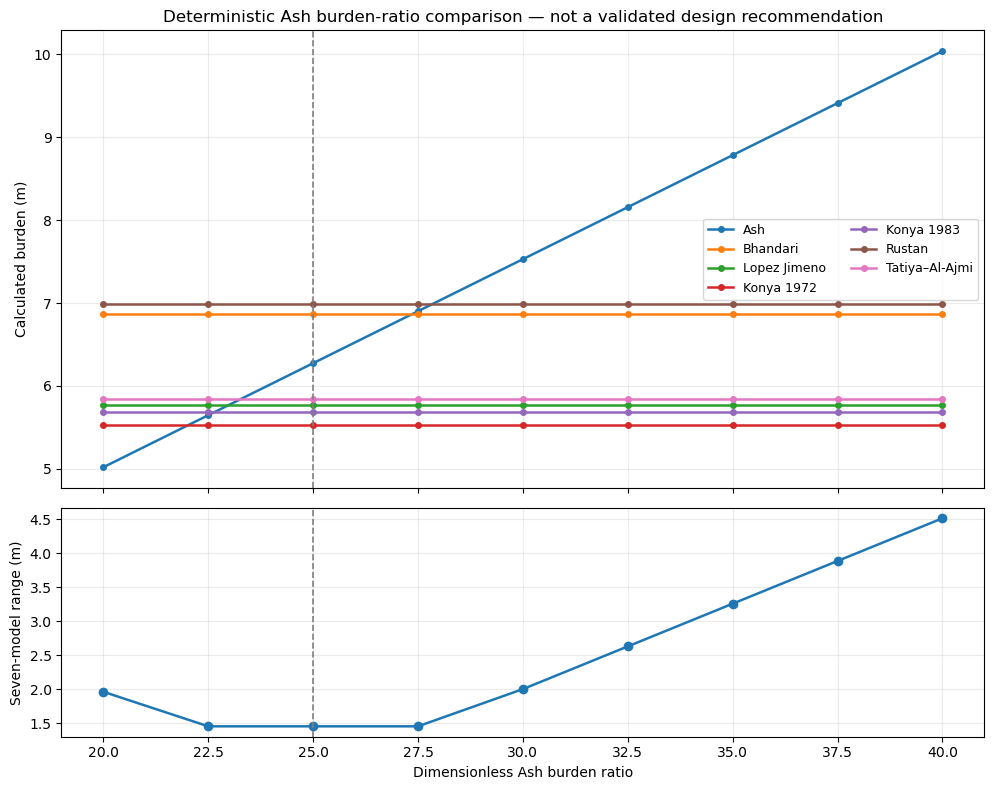

Saved figure: F:\Projects\BlastDesign-AI\outputs\figures\ash_burden_ratio_sensitivity_comparison.png


In [4]:
reference_ratio = 25.0

figure, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1],
    },
)

for model_name, group in model_outputs.groupby(
    "model_name",
    sort=False,
):
    ordered = group.sort_values(
        "ash_burden_ratio"
    )

    axes[0].plot(
        ordered["ash_burden_ratio"],
        ordered["burden_m"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=model_name,
    )

axes[0].axvline(
    reference_ratio,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)

axes[0].set_ylabel("Calculated burden (m)")
axes[0].set_title(
    "Deterministic Ash burden-ratio comparison — "
    "not a validated design recommendation"
)
axes[0].grid(alpha=0.25)
axes[0].legend(
    ncol=2,
    fontsize=9,
)

axes[1].plot(
    ensemble_summary["ash_burden_ratio"],
    ensemble_summary["range_m"],
    marker="o",
    linewidth=1.8,
)

axes[1].axvline(
    reference_ratio,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)

axes[1].set_xlabel(
    "Dimensionless Ash burden ratio"
)
axes[1].set_ylabel(
    "Seven-model range (m)"
)
axes[1].set_xticks(
    ensemble_summary["ash_burden_ratio"]
)
axes[1].grid(alpha=0.25)

figure.tight_layout()

figure_path = (
    FIGURE_DIRECTORY
    / "ash_burden_ratio_sensitivity_comparison.png"
)

figure.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", figure_path)

In [5]:
reference_row = ensemble_summary[
    ensemble_summary["ash_burden_ratio"].eq(
        reference_ratio
    )
].iloc[0]

maximum_row = ensemble_summary.loc[
    ensemble_summary["range_m"].idxmax()
]

minimum_range = ensemble_summary["range_m"].min()

minimum_rows = ensemble_summary[
    np.isclose(
        ensemble_summary["range_m"],
        minimum_range,
    )
]

minimum_ratios = (
    minimum_rows["ash_burden_ratio"]
    .tolist()
)

responsive_models = model_response_summary.loc[
    model_response_summary[
        "responds_to_ash_burden_ratio"
    ],
    "model_id",
].tolist()

ash_response = model_response_summary[
    model_response_summary["model_id"].eq(
        "CONV_ASH"
    )
].iloc[0]

print(
    "Reference seven-model range: "
    f"{reference_row['range_m']:.6f} m"
)
print(
    "Maximum sampled seven-model range: "
    f"{maximum_row['range_m']:.6f} m "
    "at Ash ratio "
    f"{maximum_row['ash_burden_ratio']:.1f}"
)
print(
    "Minimum sampled seven-model range: "
    f"{minimum_range:.6f} m "
    "at Ash ratios "
    f"{minimum_ratios}"
)
print(
    "Responding models:",
    responsive_models,
)
print(
    "Ash endpoint burden change: "
    f"{ash_response['endpoint_change_m']:.6f} m "
    f"({ash_response['endpoint_change_percent']:.1f}%)"
)

Reference seven-model range: 1.455865 m
Maximum sampled seven-model range: 4.512676 m at Ash ratio 40.0
Minimum sampled seven-model range: 1.455865 m at Ash ratios [22.5, 25.0, 27.5]
Responding models: ['CONV_ASH']
Ash endpoint burden change: 5.020000 m (100.0%)


## Interpretation

Only the Ash equation responds to the varied Ash burden ratio. The other six equations remain constant because the coefficient is not an input to those models.

Across the sampled interval:

- The Ash burden increases linearly from 5.020 m at a ratio of 20 to 10.040 m at a ratio of 40.
- The endpoint increase is 5.020 m, corresponding to 100% relative to the lower-endpoint burden.
- At the reference ratio of 25, the seven-model burden range remains approximately 1.456 m.
- The minimum sampled range forms a plateau at ratios 22.5, 25.0, and 27.5.
- This plateau is not evidence of an optimal ratio. It only indicates that, at these sampled values, the Ash estimate lies between the fixed minimum and maximum estimates produced by other equations.
- At high Ash ratios, the Ash equation becomes the upper extreme of the seven-model ensemble, substantially increasing model spread.

The Ash burden ratio is an empirical equation coefficient rather than an independently validated probabilistic variable. Consequently, these results represent deterministic parameter sensitivity and structural model disagreement—not a confidence interval, predictive uncertainty bound, calibrated design range, or site-specific operational recommendation.